# 403 — Costo computacional de los modelos ML y DL (Corrección C \#18)

Produce la tabla unificada de métricas de costo computacional para los seis modelos finales:
LogisticRegression, SGDClassifier, LightGBM, XGBoost, CNN-1D y CNN-2D.

**Fuentes:**
- **(M)** MLflow/DagsHub — duración de entrenamiento, épocas reales, hiperparámetros
- **(E)** Medición empírica local — tamaño en disco, conteo de parámetros, latencia/throughput

**Hardware:** Intel i7-12700H, 15.7 GB RAM, NVIDIA GeForce RTX 3050 Laptop GPU  
DL medido en GPU (CUDA); ML medido en CPU.

## Librerías

In [12]:
import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import json, os, time, warnings, platform
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from matplotlib.patches import Patch

import dagshub
import mlflow

from spectralcrop.utils.path_manager import PathManager

warnings.filterwarnings("ignore", category=UserWarning)

PM = PathManager()

def _resolve(path):
    if isinstance(path, list):
        return [p for p in path if 'spectralcrop' not in p][0]
    return path

_mp = PathManager().get_abs_path_folder("models")
MODELS_PATH = Path([p for p in _mp if "spectralcrop" not in p][0]) if isinstance(_mp, list) else Path(_mp)

REPORTS_PATH   = _resolve(PM.get_abs_path_folder('reports'))
FIGS_PATH    = os.path.join(REPORTS_PATH, 'figures', 'computational_cost')

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cpu_info = platform.processor()
ram_gb   = psutil.virtual_memory().total / 1024**3
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None (CPU only)"

print(f"Models path : {MODELS_PATH}")
print(f"Device      : {device}")
print(f"CPU         : {cpu_info}")
print(f"RAM         : {ram_gb:.1f} GB")
print(f"GPU         : {gpu_name}")


Models path : c:\Users\mario\Documentos\personal_projects\thesis\models
Device      : cuda
CPU         : Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
RAM         : 15.7 GB
GPU         : NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Arquitecturas DL

In [14]:
class Spectral1DCNN(nn.Module):
    def __init__(self, n_classes=2, kernel_size=5, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(1, 16, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool  = nn.AdaptiveAvgPool1d(8)
        self.fc1   = nn.Linear(32 * 8, 64)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(64, n_classes)

    def forward(self, x):  # x: [B, 1, L]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, n_channels=63, n_classes=2, dropout=0.3, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=pad)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.AdaptiveAvgPool2d((2, 2))
        self.fc1   = nn.Linear(128 * 2 * 2, 128)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(128, n_classes)

    def forward(self, x):  # x: [B, C, H, W]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

print("Arquitecturas definidas")


Arquitecturas definidas


## 2. Funciones de medición

In [15]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_file_size_kb(path: Path) -> float:
    return path.stat().st_size / 1024

def measure_inference_dl(model: nn.Module, input_shape: tuple,
                         n_warmup: int = 100, n_samples: int = 10_000,
                         batch_size: int = 512) -> dict:
    """Latencia y throughput de inferencia para nn.Module en GPU/CPU."""
    model.eval()
    model.to(device)
    with torch.no_grad():
        for _ in range(max(1, n_warmup // batch_size)):
            _ = model(torch.randn(batch_size, *input_shape, device=device))
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
    mem_before = psutil.Process(os.getpid()).memory_info().rss / 1024**2
    n_batches = (n_samples + batch_size - 1) // batch_size
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_batches):
            _ = model(torch.randn(batch_size, *input_shape, device=device))
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    mem_after = psutil.Process(os.getpid()).memory_info().rss / 1024**2
    peak_mem_mb = (torch.cuda.max_memory_allocated() / 1024**2
                   if device.type == "cuda" else max(mem_after - mem_before, 0.0))
    total = n_batches * batch_size
    return {
        "throughput_samples_s": round(total / elapsed, 1),
        "latency_batch_ms":     round(elapsed / n_batches * 1000, 2),
        "time_1M_pixels_s":     round(1_000_000 / (total / elapsed), 1),
        "peak_mem_mb":          round(peak_mem_mb, 1),
    }

def measure_inference_ml(predict_fn, n_features: int,
                         n_warmup: int = 200, n_samples: int = 10_000,
                         batch_size: int = 512) -> dict:
    """Latencia y throughput de inferencia para modelos sklearn/lgbm/xgb en CPU."""
    predict_fn(np.random.randn(min(n_warmup, 512), n_features).astype(np.float32))
    mem_before = psutil.Process(os.getpid()).memory_info().rss / 1024**2
    n_batches = (n_samples + batch_size - 1) // batch_size
    t0 = time.perf_counter()
    for _ in range(n_batches):
        predict_fn(np.random.randn(batch_size, n_features).astype(np.float32))
    elapsed = time.perf_counter() - t0
    mem_after = psutil.Process(os.getpid()).memory_info().rss / 1024**2
    total = n_batches * batch_size
    return {
        "throughput_samples_s": round(total / elapsed, 1),
        "latency_batch_ms":     round(elapsed / n_batches * 1000, 2),
        "time_1M_pixels_s":     round(1_000_000 / (total / elapsed), 1),
        "peak_mem_mb":          round(max(mem_after - mem_before, 0.0), 1),
    }

print("Funciones definidas")


Funciones definidas


## 3. Conexión MLflow — métricas de entrenamiento

In [16]:
dagshub.init(repo_owner="johnma96", repo_name="thesis", mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/johnma96/thesis.mlflow")
client = mlflow.MlflowClient()

# CNN-2D
RUN_ID_2D = "61a3cc05f39d46f79f2e3fa3d29fae7f"
run_2d  = client.get_run(RUN_ID_2D)
dur_2d  = (run_2d.info.end_time - run_2d.info.start_time) / 1000
hist_2d = client.get_metric_history(RUN_ID_2D, "val_pr_auc")
epochs_2d = len(hist_2d)
print(f"CNN-2D: dur={dur_2d:.0f}s ({dur_2d/60:.1f}min), epocas={epochs_2d}/{run_2d.data.params['max_epochs']}")

# CNN-1D
exp_1d = mlflow.get_experiment_by_name("cnn1d")
run_1d = client.search_runs(
    experiment_ids=[exp_1d.experiment_id],
    filter_string='tags.mlflow.runName = "cnn1d_final_model"',
    order_by=["metrics.test_pr_auc DESC"], max_results=1,
)[0]
dur_1d    = (run_1d.info.end_time - run_1d.info.start_time) / 1000
hist_1d   = client.get_metric_history(run_1d.info.run_id, "val_pr_auc")
epochs_1d = len(hist_1d)
print(f"CNN-1D: dur={dur_1d:.0f}s ({dur_1d/60:.1f}min), epocas={epochs_1d}/{run_1d.data.params['max_epochs']}")

# Tiempos HPO totales (todos los runs de cada experimento)
def total_exp_s(exp_name: str) -> float:
    exp = mlflow.get_experiment_by_name(exp_name)
    if exp is None:
        return 0.0
    runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=200)
    return sum((r.info.end_time - r.info.start_time) / 1000
               for r in runs if r.info.end_time)

hpo_totals = {
    "LogisticRegression": total_exp_s("logisticregression"),
    "SGDClassifier":      total_exp_s("sgdclassifier"),
    "LightGBM":           total_exp_s("lgbmclassifier"),
    "XGBoost":            total_exp_s("xgboost"),
    "CNN-1D":             total_exp_s("cnn1d"),
    "CNN-2D":             total_exp_s("cnn2d"),
}

# Tiempos run final ML
all_exp_ids = [e.experiment_id for e in client.search_experiments()]
ml_run_names_map = {
    "LogisticRegression": "logreg_cv_final_model",
    "SGDClassifier":      "sgd_cv_final_model",
    "LightGBM":           "lgbm_cv_final_model",
    "XGBoost":            "xgboost_cv_final_model",
}
ml_train_s = {}
for name, rname in ml_run_names_map.items():
    found = client.search_runs(
        experiment_ids=all_exp_ids,
        filter_string=f'tags.mlflow.runName = "{rname}"',
        order_by=["metrics.test_pr_auc DESC"], max_results=1,
    )
    if found:
        r = found[0]
        ml_train_s[name] = (r.info.end_time - r.info.start_time) / 1000

print("\nRun final ML (s):", {k: round(v) for k, v in ml_train_s.items()})
print("HPO total (s):   ", {k: round(v) for k, v in hpo_totals.items()})


Initialized MLflow to track repo "johnma96/thesis"

Repository johnma96/thesis initialized!

CNN-2D: dur=1051s (17.5min), epocas=22/80
CNN-1D: dur=3496s (58.3min), epocas=109/200

Run final ML (s): {'LogisticRegression': 208, 'SGDClassifier': 173, 'LightGBM': 115, 'XGBoost': 2130}
HPO total (s):    {'LogisticRegression': 7409, 'SGDClassifier': 952, 'LightGBM': 542, 'XGBoost': 37373, 'CNN-1D': 54743, 'CNN-2D': 37322}


## 4. Carga y medición — modelos DL

In [17]:
with open(MODELS_PATH / "cnn1d_final_model_info.json") as f:
    info1d = json.load(f)

model1d = Spectral1DCNN(
    n_classes=2, kernel_size=info1d["kernel_size"], dropout=info1d["dropout"],
).to(device)
model1d.load_state_dict(
    torch.load(MODELS_PATH / "cnn1d_final_model_weights.pt",
               map_location=device, weights_only=False))
model1d.eval()
n_params_1d = count_parameters(model1d)
size_1d_kb  = get_file_size_kb(MODELS_PATH / "cnn1d_final_model_weights.pt")
cost_1d     = measure_inference_dl(model1d, input_shape=(1, info1d["input_len"]))
print(f"CNN-1D  params={n_params_1d:,}  size={size_1d_kb:.1f} KB")
print(f"        {cost_1d}")

with open(MODELS_PATH / "cnn2d_final_model_info.json") as f:
    info2d = json.load(f)

model2d = SpectralSpatialCNN2D(
    n_channels=info2d["n_channels"], dropout=info2d["dropout"], kernel_size=info2d["kernel_size"],
).to(device)
model2d.load_state_dict(
    torch.load(MODELS_PATH / "cnn2d_final_model_weights.pt",
               map_location=device, weights_only=False))
model2d.eval()
n_params_2d = count_parameters(model2d)
size_2d_kb  = get_file_size_kb(MODELS_PATH / "cnn2d_final_model_weights.pt")
cost_2d     = measure_inference_dl(model2d, input_shape=(info2d["n_channels"], info2d["patch_size"], info2d["patch_size"]))
print(f"CNN-2D  params={n_params_2d:,}  size={size_2d_kb/1024:.2f} MB")
print(f"        {cost_2d}")


CNN-1D  params=21,474  size=91.0 KB
        {'throughput_samples_s': 52446.2, 'latency_batch_ms': 9.76, 'time_1M_pixels_s': 19.1, 'peak_mem_mb': 22.6}
CNN-2D  params=372,994  size=1.43 MB
        {'throughput_samples_s': 108827.7, 'latency_batch_ms': 4.7, 'time_1M_pixels_s': 9.2, 'peak_mem_mb': 29.3}


## 5. Carga y medición — modelos ML

In [18]:
N_FEAT = 63
ml_model_files = {
    "LogisticRegression": "logreg_cv_final_model.pkl",
    "SGDClassifier":      "sgd_cv_final_model.pkl",
    "LightGBM":           "lgbm_cv_final_model.pkl",
    "XGBoost":            "xgboost_cv_final_model.pkl",
}

ml_results = {}
for name, fname in ml_model_files.items():
    fpath = MODELS_PATH / fname
    pipe  = joblib.load(fpath)
    size_kb = get_file_size_kb(fpath)
    est = list(pipe.named_steps.values())[-1] if hasattr(pipe, "named_steps") else pipe

    if hasattr(est, "coef_"):
        n_total = est.coef_.size + est.intercept_.size
        param_info = f"{n_total} coeficientes"
    elif hasattr(est, "booster_"):
        n_t = est.booster_.num_trees()
        # n_t=1 due to early_stopping_rounds conflict in training (both constructor
        # param and callback were active simultaneously — see notebook 304, cell 177)
        param_info = f"{n_t} árbol(es), num_leaves={est.num_leaves}"
    elif hasattr(est, "get_booster"):
        n_t = int(est.get_booster().num_boosted_rounds())
        param_info = f"{n_t} árboles, max_depth={est.max_depth}"
    else:
        param_info = "N/A"

    cost = measure_inference_ml(pipe.predict_proba, n_features=N_FEAT)
    ml_results[name] = {"size_kb": round(size_kb, 1), "param_info": param_info, "cost": cost}
    print(f"{name:22s}  {size_kb:.1f} KB  {param_info}")
    print(f"  {cost}")


LogisticRegression      2.8 KB  64 coeficientes
  {'throughput_samples_s': 483331.2, 'latency_batch_ms': 1.06, 'time_1M_pixels_s': 2.1, 'peak_mem_mb': 0.5}
SGDClassifier           2.9 KB  64 coeficientes
  {'throughput_samples_s': 454257.1, 'latency_batch_ms': 1.13, 'time_1M_pixels_s': 2.2, 'peak_mem_mb': 0.0}
LightGBM                30.2 KB  1 árbol(es), num_leaves=123
  {'throughput_samples_s': 221204.5, 'latency_batch_ms': 2.31, 'time_1M_pixels_s': 4.5, 'peak_mem_mb': 0.0}
XGBoost                 35911.1 KB  3552 árboles, max_depth=8
  {'throughput_samples_s': 34684.6, 'latency_batch_ms': 14.76, 'time_1M_pixels_s': 28.8, 'peak_mem_mb': 0.4}


## 6. Tabla resumen unificada

In [19]:
def fmt_s(s):
    if s is None: return "N/D"
    s = int(s)
    if s < 3600: return f"{s//60} min {s%60:02d} s"
    return f"{s//3600}h {(s%3600)//60}min"

COLS = ["LogisticRegression", "SGDClassifier", "LightGBM", "XGBoost", "CNN-1D", "CNN-2D"]

gpu_label = "RTX 3050"
rows = {
    "Tamaño en disco": {
        "LogisticRegression": f"{ml_results['LogisticRegression']['size_kb']:.1f} KB",
        "SGDClassifier":      f"{ml_results['SGDClassifier']['size_kb']:.1f} KB",
        "LightGBM":           f"{ml_results['LightGBM']['size_kb']:.1f} KB",
        "XGBoost":            f"{ml_results['XGBoost']['size_kb']/1024:.1f} MB",
        "CNN-1D":             f"{size_1d_kb:.1f} KB",
        "CNN-2D":             f"{size_2d_kb/1024:.2f} MB",
    },
    "Estructura interna": {
        "LogisticRegression": ml_results["LogisticRegression"]["param_info"],
        "SGDClassifier":      ml_results["SGDClassifier"]["param_info"],
        "LightGBM":           ml_results["LightGBM"]["param_info"],
        "XGBoost":            ml_results["XGBoost"]["param_info"],
        "CNN-1D":             f"{n_params_1d:,} parámetros",
        "CNN-2D":             f"{n_params_2d:,} parámetros",
    },
    "Entrenamiento run final (M)": {k: fmt_s(ml_train_s.get(k)) for k in COLS[:4]} | {
        "CNN-1D": fmt_s(dur_1d), "CNN-2D": fmt_s(dur_2d),
    },
    "HPO total acumulado (M)": {k: fmt_s(hpo_totals.get(k)) for k in COLS},
    "Épocas entrenadas (M)": {
        "LogisticRegression": "N/A", "SGDClassifier": "N/A",
        "LightGBM": "N/A",          "XGBoost": "N/A",
        "CNN-1D": f"{epochs_1d} / {run_1d.data.params['max_epochs']}",
        "CNN-2D": f"{epochs_2d} / {run_2d.data.params['max_epochs']}",
    },
    "Hardware inferencia (E)": {
        "LogisticRegression": "CPU", "SGDClassifier": "CPU",
        "LightGBM": "CPU",           "XGBoost": "CPU",
        "CNN-1D": f"GPU ({gpu_label})", "CNN-2D": f"GPU ({gpu_label})",
    },
    "Mem. pico inferencia MB (E)": {
        k: f"{ml_results[k]['cost']['peak_mem_mb']:.1f}" for k in COLS[:4]
    } | {"CNN-1D": f"{cost_1d['peak_mem_mb']:.1f}", "CNN-2D": f"{cost_2d['peak_mem_mb']:.1f}"},
    "Latencia batch-512 ms (E)": {
        k: f"{ml_results[k]['cost']['latency_batch_ms']:.2f}" for k in COLS[:4]
    } | {"CNN-1D": f"{cost_1d['latency_batch_ms']:.2f}", "CNN-2D": f"{cost_2d['latency_batch_ms']:.2f}"},
    "Throughput muestras/s (E)": {
        k: f"{ml_results[k]['cost']['throughput_samples_s']:,.0f}" for k in COLS[:4]
    } | {"CNN-1D": f"{cost_1d['throughput_samples_s']:,.0f}", "CNN-2D": f"{cost_2d['throughput_samples_s']:,.0f}"},
    "Tiempo 1M píxeles s (E)": {
        k: f"{ml_results[k]['cost']['time_1M_pixels_s']:.1f}" for k in COLS[:4]
    } | {"CNN-1D": f"{cost_1d['time_1M_pixels_s']:.1f}", "CNN-2D": f"{cost_2d['time_1M_pixels_s']:.1f}"},
}

df = pd.DataFrame(rows).T
df.index.name = "Métrica"
df = df[COLS]
df


,LogisticRegression,SGDClassifier,LightGBM,XGBoost,CNN-1D,CNN-2D
Métrica,,,,,,
Tamaño en disco,2.8 KB,2.9 KB,30.2 KB,35.1 MB,91.0 KB,1.43 MB
Estructura interna,64 coeficientes,64 coeficientes,"1 árbol(es), num_leaves=123","3552 árboles, max_depth=8","21,474 parámetros","372,994 parámetros"
Entrenamiento run final (M),3 min 28 s,2 min 53 s,1 min 54 s,35 min 30 s,58 min 15 s,17 min 31 s
HPO total acumulado (M),2h 3min,15 min 52 s,9 min 02 s,10h 22min,15h 12min,10h 22min
Épocas entrenadas (M),N/A,N/A,N/A,N/A,109 / 200,22 / 80
Hardware inferencia (E),CPU,CPU,CPU,CPU,GPU (RTX 3050),GPU (RTX 3050)
Mem. pico inferencia MB (E),0.5,0.0,0.0,0.4,22.6,29.3
Latencia batch-512 ms (E),1.06,1.13,2.31,14.76,9.76,4.70
Throughput muestras/s (E),"483,331","454,257","221,204","34,685","52,446","108,828"


In [23]:
Path(FIGS_PATH) / "computational_cost_summary.csv"

WindowsPath('c:/Users/mario/Documentos/personal_projects/thesis/reports/figures/computational_cost/computational_cost_summary.csv')

In [26]:
df.to_csv(Path(FIGS_PATH) / "computational_cost_summary.csv")

md_lines = [
    "# Tabla costo computacional — Corrección C #18",
    "",
    f"Hardware inferencia: CPU (modelos ML) | GPU {gpu_name} (CNN-1D, CNN-2D)",
    f"CPU: {cpu_info} | RAM: {ram_gb:.1f} GB",
    "(M) = dato de MLflow | (E) = medición empírica local",
    "",
    "| Métrica | " + " | ".join(COLS) + " |",
    "|" + "---|" * (len(COLS) + 1),
]
for metric, row in rows.items():
    md_lines.append("| " + metric + " | " + " | ".join(str(row[c]) for c in COLS) + " |")

md_text = "\n".join(md_lines)
with open(Path(FIGS_PATH) / "computational_cost_summary.csv", "w", encoding="utf-8") as f:
    f.write(md_text)

print("Archivos guardados en", FIGS_PATH)
print()
print(md_text)


Archivos guardados en c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\computational_cost

# Tabla costo computacional — Corrección C #18

Hardware inferencia: CPU (modelos ML) | GPU NVIDIA GeForce RTX 3050 Laptop GPU (CNN-1D, CNN-2D)
CPU: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel | RAM: 15.7 GB
(M) = dato de MLflow | (E) = medición empírica local

| Métrica | LogisticRegression | SGDClassifier | LightGBM | XGBoost | CNN-1D | CNN-2D |
|---|---|---|---|---|---|---|
| Tamaño en disco | 2.8 KB | 2.9 KB | 30.2 KB | 35.1 MB | 91.0 KB | 1.43 MB |
| Estructura interna | 64 coeficientes | 64 coeficientes | 1 árbol(es), num_leaves=123 | 3552 árboles, max_depth=8 | 21,474 parámetros | 372,994 parámetros |
| Entrenamiento run final (M) | 3 min 28 s | 2 min 53 s | 1 min 54 s | 35 min 30 s | 58 min 15 s | 17 min 31 s |
| HPO total acumulado (M) | 2h 3min | 15 min 52 s | 9 min 02 s | 10h 22min | 15h 12min | 10h 22min |
| Épocas entrenadas (M) | N/A | N/A | N/A | N/A | 109

## 7. Visualización — comparativa de eficiencia de inferencia

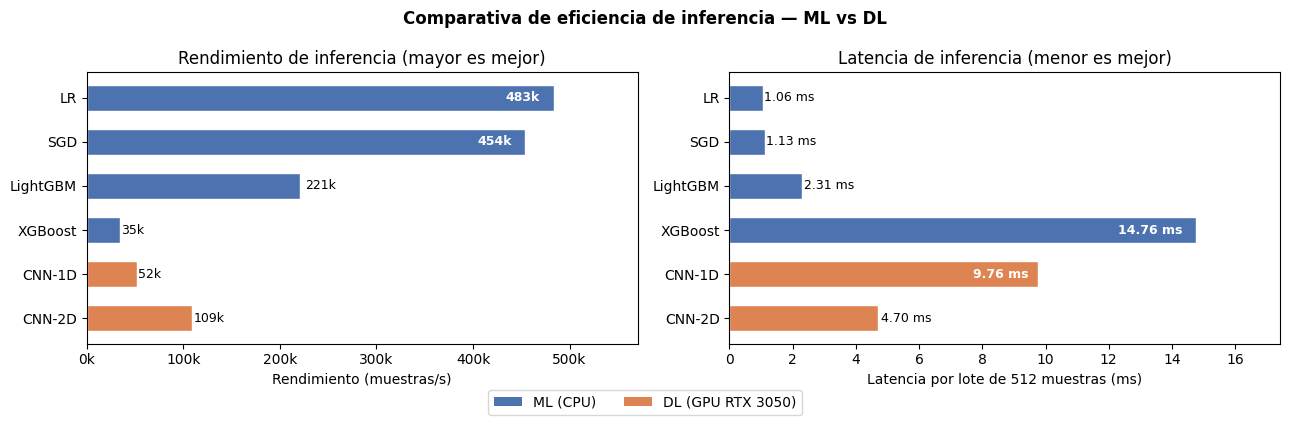

Figura guardada: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\computational_cost\inference_comparison.png


In [28]:
INSIDE_THRESHOLD = 0.60  # si la barra supera este % del max, texto va dentro

def add_labels_hbar(ax, bars, values, fmt_fn, max_val):
    for bar, v in zip(bars, values):
        w = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        if w / max_val > INSIDE_THRESHOLD:
            ax.text(w * 0.97, y, fmt_fn(v),
                    va="center", ha="right", fontsize=9, color="white", fontweight="bold")
        else:
            ax.text(w * 1.02, y, fmt_fn(v),
                    va="center", ha="left", fontsize=9, color="black")

LABELS = ["LR", "SGD", "LightGBM", "XGBoost", "CNN-1D", "CNN-2D"]
throughputs = [ml_results[k]["cost"]["throughput_samples_s"] for k in COLS[:4]] + [cost_1d["throughput_samples_s"], cost_2d["throughput_samples_s"]]
latencies   = [ml_results[k]["cost"]["latency_batch_ms"] for k in COLS[:4]] + [cost_1d["latency_batch_ms"], cost_2d["latency_batch_ms"]]
colors      = ["#4C72B0"] * 4 + ["#DD8452"] * 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.barh(LABELS, throughputs, color=colors, edgecolor="white", height=0.6)
ax.set_xlabel("Rendimiento (muestras/s)")
ax.set_title("Rendimiento de inferencia (mayor es mejor)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.invert_yaxis()
ax.set_xlim(0, max(throughputs) * 1.18)
add_labels_hbar(ax, bars, throughputs, lambda v: f"{v/1000:.0f}k", max(throughputs))

ax2 = axes[1]
bars2 = ax2.barh(LABELS, latencies, color=colors, edgecolor="white", height=0.6)
ax2.set_xlabel("Latencia por lote de 512 muestras (ms)")
ax2.set_title("Latencia de inferencia (menor es mejor)")
ax2.invert_yaxis()
ax2.set_xlim(0, max(latencies) * 1.18)
add_labels_hbar(ax2, bars2, latencies, lambda v: f"{v:.2f} ms", max(latencies))

legend_elems = [Patch(facecolor="#4C72B0", label="ML (CPU)"),
                Patch(facecolor="#DD8452", label=f"DL (GPU {gpu_label})")]
fig.legend(handles=legend_elems, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Comparativa de eficiencia de inferencia — ML vs DL", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(Path(FIGS_PATH) / "inference_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada:", Path(FIGS_PATH) / "inference_comparison.png")


## Nota de hardware para el jurado

Las métricas de inferencia empíricas dependen del hardware de ejecución. Todas las mediciones de este notebook se realizaron en el equipo de desarrollo:

- **CPU:** Intel Core i7-12700H (Intel64 Family 6 Model 154 Stepping 3)
- **RAM:** 15.7 GB
- **GPU:** NVIDIA GeForce RTX 3050 Laptop GPU (CUDA)
- **SO:** Windows 11

Los modelos ML (LR, SGD, LightGBM, XGBoost) se midieron en **CPU**, ya que sus implementaciones no requieren GPU para inferencia en producción. Los modelos DL (CNN-1D, CNN-2D) se midieron en **GPU** porque PyTorch detectó CUDA disponible. Para una comparación en igualdad de condiciones, los CNN en CPU serían ~5-10× más lentos, lo cual reduciría la brecha con los modelos ML pero mantendría el ranking relativo.

**Nota LightGBM:** el modelo final entrenado contiene 1 árbol (early stopping disparó en la iteración 1 durante el refit final debido a un conflicto entre el parámetro `early_stopping_rounds` del constructor y el callback `lgbm.early_stopping()` — ver notebook 304, función `train_lgbm_pipeline_cv`, sección 2). El modelo es válido y reporta PR-AUC=0.782 en test.